# NLP CW - EDA

# 0. Imports and setup

In [10]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from urllib import request
from pathlib import Path


In [3]:
# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Setup complete.")

Setup complete.


# 1. Data Loading

In [4]:
module_url = f"https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py"
module_name = module_url.split('/')[-1]
print(f'Fetching {module_url}')
#with open("file_1.txt") as f1, open("file_2.txt") as f2
with request.urlopen(module_url) as f, open(module_name,'w') as outf:
  a = f.read()
  outf.write(a.decode('utf-8'))

from dont_patronize_me import DontPatronizeMe

dpm = DontPatronizeMe('.', '.')

dpm.load_task1()

trids = pd.read_csv('train_semeval_parids-labels.csv')
teids = pd.read_csv('dev_semeval_parids-labels.csv')

trids.par_id = trids.par_id.astype(str)
teids.par_id = teids.par_id.astype(str)

data=dpm.train_task1_df

data


Fetching https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py


,par_id,art_id,keyword,country,text,label,orig_label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0,0
...,...,...,...,...,...,...,...
10464,10465,@@14297363,women,lk,"""Sri Lankan norms and culture inhibit women fr...",0,1
10465,10466,@@70091353,vulnerable,ph,He added that the AFP will continue to bank on...,0,0
10466,10467,@@20282330,in-need,ng,""""""" She has one huge platform , and informatio...",1,3
10467,10468,@@16753236,hopeless,in,""""""" Anja Ringgren Loven I ca n't find a word t...",1,4


### Split the data to train and dev sets according to 'par_id' in CSV files

In [5]:
data_merged = data.copy()
data_merged["par_id"] = data_merged["par_id"].astype(str)

trids = trids.copy()
teids = teids.copy()
trids["par_id"] = trids["par_id"].astype(str)
teids["par_id"] = teids["par_id"].astype(str)

# Merge official split IDs with reconstructed dataset
df_train = trids.merge(data_merged, on="par_id", how="left", suffixes=("_csv", "_data"))
df_dev = teids.merge(data_merged, on="par_id", how="left", suffixes=("_csv", "_data"))

print("Train shape:", df_train.shape)
print("Dev shape:", df_dev.shape)

print("Missing text in train:", df_train["text"].isna().sum())
print("Missing text in dev:", df_dev["text"].isna().sum())


Train shape: (8375, 8)
Dev shape: (2094, 8)
Missing text in train: 0
Missing text in dev: 0


### Display data for inspection

In [6]:
df_train


,par_id,label_csv,art_id,keyword,country,text,label_data,orig_label
0,4341,"[1, 0, 0, 1, 0, 0, 0]",@@17139403,poor-families,gb,"The scheme saw an estimated 150,000 children f...",1,4
1,4136,"[0, 1, 0, 0, 0, 0, 0]",@@22273328,homeless,za,Durban 's homeless communities reconciliation ...,1,2
2,10352,"[1, 0, 0, 0, 0, 1, 0]",@@21102155,poor-families,lk,The next immediate problem that cropped up was...,1,4
3,8279,"[0, 0, 0, 1, 0, 0, 0]",@@21220476,vulnerable,nz,Far more important than the implications for t...,1,2
4,1164,"[1, 0, 0, 1, 1, 1, 0]",@@14727121,poor-families,gh,To strengthen child-sensitive social protectio...,1,4
...,...,...,...,...,...,...,...,...
8370,8380,"[0, 0, 0, 0, 0, 0, 0]",@@3172947,refugee,gb,Rescue teams search for survivors on the rubbl...,0,0
8371,8381,"[0, 0, 0, 0, 0, 0, 0]",@@23593795,hopeless,ke,The launch of ' Happy Birthday ' took place la...,0,0
8372,8382,"[0, 0, 0, 0, 0, 0, 0]",@@9222273,homeless,pk,"The unrest has left at least 20,000 people dea...",0,0
8373,8383,"[0, 0, 0, 0, 0, 0, 0]",@@25979256,hopeless,pk,You have to see it from my perspective . I may...,0,0


### Label preprocessing for later tasks

In [7]:
label_cols_train = [c for c in df_train.columns if "label" in c.lower()]
label_cols_dev = [c for c in df_dev.columns if "label" in c.lower()]

print("Train label columns:", label_cols_train)
print("Dev label columns:", label_cols_dev)

# Example if columns are 'label_csv' and 'label_data'
if "label_csv" in df_train.columns and "label_data" in df_train.columns:
    print("Train label match rate:", (df_train["label_csv"] == df_train["label_data"]).mean())
if "label_csv" in df_dev.columns and "label_data" in df_dev.columns:
    print("Dev label match rate:", (df_dev["label_csv"] == df_dev["label_data"]).mean())


Train label columns: ['label_csv', 'label_data', 'orig_label']
Dev label columns: ['label_csv', 'label_data', 'orig_label']
Train label match rate: 0.0
Dev label match rate: 0.0


# 2. Exploratory Data Analysis (EDA)

This section includes thorough EDA for the Don't Patronize Me dataset.

It covers:
- Basic Statistical Profiling
- Lexical Analysis
- Semantic & Syntactic Exploration
- Identifying "Noise" and Artifacts

## 2.1 Basic Statistical Profiling

### We start by analysing the data split and class distribution

In [8]:
def split_summary(df, split_name):
    n = len(df)
    counts = df["label_data"].value_counts().sort_index()
    n_neg = int(counts.get(0, 0))
    n_pos = int(counts.get(1, 0))
    pos_rate = n_pos / n if n > 0 else np.nan
    neg_rate = n_neg / n if n > 0 else np.nan
    imbalance_ratio = (n_neg / n_pos) if n_pos > 0 else np.inf  
    return {
        "split": split_name,
        "n_samples": n,
        "n_neg (0)": n_neg,
        "n_pos (1)": n_pos,
        "neg_rate": neg_rate,
        "pos_rate": pos_rate,
        "imbalance_ratio": imbalance_ratio,
    }

summary_rows = [
    split_summary(df_train, "train"),
    split_summary(df_dev, "dev"),
]

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df.style.format({
        "neg_rate": "{:.2%}",
        "pos_rate": "{:.2%}",
        "imbalance_ratio": "{:.2f}"
    })
)

print("Combined samples (train + dev):", len(df_train) + len(df_dev))

,split,n_samples,n_neg (0),n_pos (1),neg_rate,pos_rate,imbalance_ratio
0,train,8375,7581,794,90.52%,9.48%,9.55
1,dev,2094,1895,199,90.50%,9.50%,9.52


Combined samples (train + dev): 10469


### Plot data distribution for visualisation

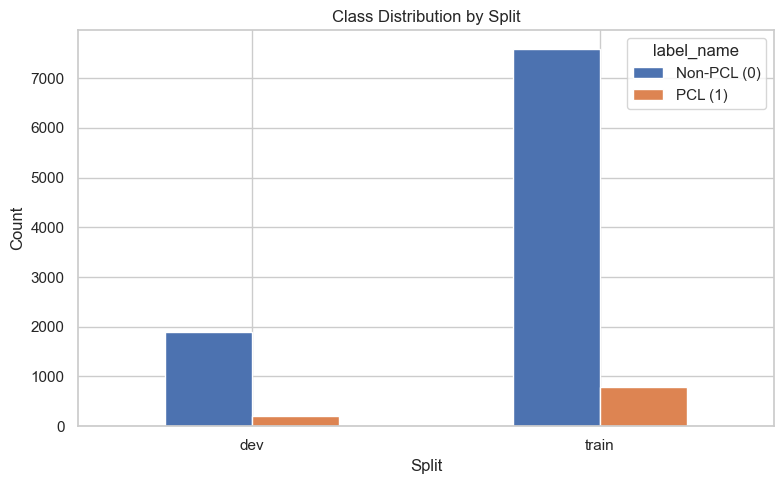

In [11]:
plot_df = pd.concat([
    df_train.assign(split="train"),
    df_dev.assign(split="dev")
], ignore_index=True)

class_counts = (
    plot_df.groupby(["split", "label_data"])
    .size()
    .reset_index(name="count")
)

# Map labels for readability
class_counts["label_name"] = class_counts["label_data"].map({0: "Non-PCL (0)", 1: "PCL (1)"})

# Pivot for plotting
pivot_counts = class_counts.pivot(index="split", columns="label_name", values="count").fillna(0)

ax = pivot_counts.plot(kind="bar", rot=0)
ax.set_title("Class Distribution by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(Path("figures") / "eda_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Now we consider char-level and word-level text length profiling

In [12]:
def add_basic_length_features(df):
    df = df.copy()
    df["text"] = df["text"].fillna("").astype(str)
    df["char_len"] = df["text"].str.len()
    # simple whitespace tokenization for rough profiling
    df["word_len"] = df["text"].str.split().str.len()
    return df

df_train = add_basic_length_features(df_train)
df_dev = add_basic_length_features(df_dev)

def length_summary(df, split_name):
    stats = {}
    for col in ["char_len", "word_len"]:
        s = df[col]
        stats.update({
            f"{col}_min": int(s.min()),
            f"{col}_mean": float(s.mean()),
            f"{col}_max": int(s.max()),
        })
    stats["split"] = split_name
    return stats

len_summary_df = pd.DataFrame([
    length_summary(df_train, "train"),
    length_summary(df_dev, "dev")
])

# reorder columns nicely
cols = ["split"] + [c for c in len_summary_df.columns if c != "split"]
len_summary_df = len_summary_df[cols]

display(len_summary_df.round(2))

,split,char_len_min,char_len_mean,char_len_max,word_len_min,word_len_mean,word_len_max
0,train,8,268.94,5501,1,48.68,909
1,dev,0,262.15,1446,0,47.41,272


### Above table shows very long paragraphs in training data and some empty paragraphs in dev data. Below we are printing out those outliers for verification.

In [13]:
# Empty/zero-length dev texts
df_dev[df_dev["word_len"] == 0][["par_id", "text", "label_data", "orig_label"]].head(10)

,par_id,text,label_data,orig_label
434,8640,,0,0


In [14]:
# Longest train texts
df_train.sort_values("word_len", ascending=False)[["par_id", "word_len", "char_len", "text"]].head(5)

,par_id,word_len,char_len,text
7489,7419,909,5501,"""Dr Mayengbam Lalit Singh Recently honourable ..."
643,6833,512,2784,"""Most are from desperately poor Horn of Africa..."
6207,5978,419,2346,"""Mahinda Wijesinghe , the Inspector General of..."
8203,8192,390,2240,ANNUAL State of Education Report ( ASER ) laun...
1058,293,266,1512,"""The following is a brief history of the Rajne..."


### This section compares paragraph word-length distributions across train/dev splits and PCL vs non-PCL classes to assess whether text length differs by label and may affect modelling difficulty or truncation sensitivity.

,split,label_data,count,mean,median,min,max
0,dev,0,1895,46.72,41.0,0,272
1,dev,1,199,54.02,47.0,11,175
2,train,0,7581,48.17,42.0,1,909
3,train,1,794,53.52,47.0,6,512


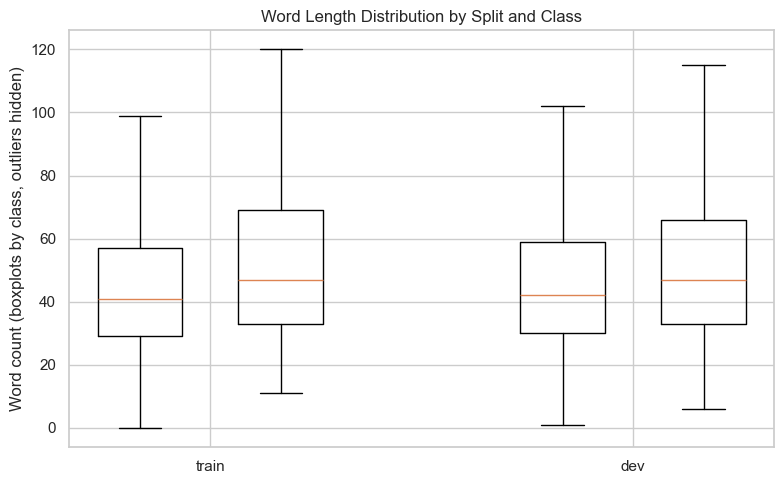

In [15]:
length_by_class = (
    pd.concat([df_train.assign(split="train"), df_dev.assign(split="dev")], ignore_index=True)
    .groupby(["split", "label_data"])["word_len"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

display(length_by_class.round(2))

# Optional boxplot (can be noisy due to outliers)
plot_df_len = pd.concat([df_train.assign(split="train"), df_dev.assign(split="dev")], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
for i, (split_name, split_df) in enumerate(plot_df_len.groupby("split")):
    # Create separate positions for labels 0 and 1
    for j, label in enumerate([0, 1]):
        vals = split_df.loc[split_df["label_data"] == label, "word_len"].dropna().values
        pos = i * 3 + j + 1
        ax.boxplot(vals, positions=[pos], widths=0.6, showfliers=False)

ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["train", "dev"])
ax.set_ylabel("Word count (boxplots by class, outliers hidden)")
ax.set_title("Word Length Distribution by Split and Class")
plt.tight_layout()
plt.show()

### Now we move to measures the distribution of tokenized input lengths (using the RoBERTa tokenizer) and estimates truncation rates at different `max_length` values to guide a practical trade-off between computational efficiency and information loss during model training.

/Users/Khalid/Desktop/University/NLP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Token indices sequence length is longer than the specified maximum sequence length for this model (546 > 512). Running this sequence through the model will result in indexing errors


,split,token_len_min,token_len_mean,token_len_median,token_len_p90,token_len_p95,token_len_p99,token_len_max
0,train,5,55.91,49.0,95.0,115.3,160.26,1005
1,dev,2,54.54,48.0,92.0,112.0,158.00,355


,split,max_length,n_truncated,truncation_rate
0,train,64,2396,28.61%
1,train,128,271,3.24%
2,train,256,7,0.08%
3,train,384,4,0.05%
4,train,512,2,0.02%
5,dev,64,564,26.93%
6,dev,128,53,2.53%
7,dev,256,1,0.05%
8,dev,384,0,0.00%
9,dev,512,0,0.00%


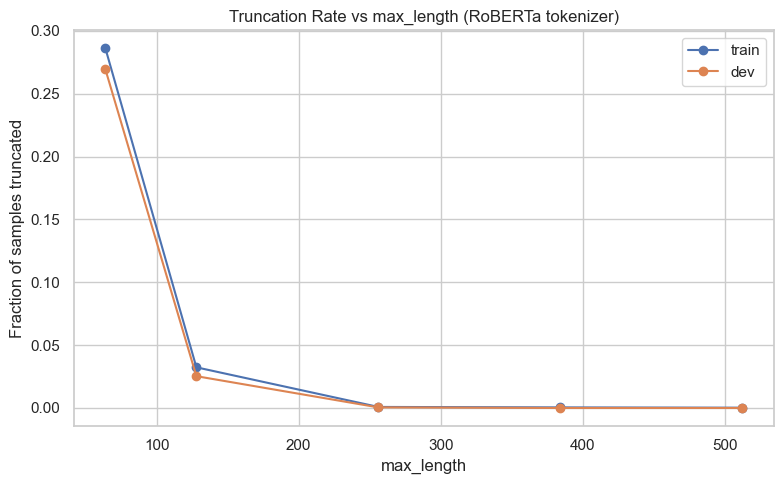

In [ ]:
from transformers import AutoTokenizer

# Use baseline-compatible tokenizer (RoBERTa)
tokenizer_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

def compute_token_lengths(texts, tokenizer, batch_size=256):
    lengths = []
    texts = ["" if pd.isna(t) else str(t) for t in texts]
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, add_special_tokens=True, truncation=False, padding=False)
        lengths.extend([len(ids) for ids in enc["input_ids"]])
    return lengths

# Compute token lengths (can take a little time, but manageable)
df_train["token_len"] = compute_token_lengths(df_train["text"].tolist(), tokenizer)
df_dev["token_len"] = compute_token_lengths(df_dev["text"].tolist(), tokenizer)

def token_summary(df, split_name):
    s = df["token_len"]
    return {
        "split": split_name,
        "token_len_min": int(s.min()),
        "token_len_mean": float(s.mean()),
        "token_len_median": float(s.median()),
        "token_len_p90": float(s.quantile(0.90)),
        "token_len_p95": float(s.quantile(0.95)),
        "token_len_p99": float(s.quantile(0.99)),
        "token_len_max": int(s.max()),
    }

token_summary_df = pd.DataFrame([
    token_summary(df_train, "train"),
    token_summary(df_dev, "dev")
])

display(token_summary_df.round(2))

# Truncation rates for candidate max lengths
candidate_max_lengths = [64, 128, 256, 384, 512]

trunc_rows = []
for split_name, df_ in [("train", df_train), ("dev", df_dev)]:
    n = len(df_)
    for m in candidate_max_lengths:
        n_trunc = int((df_["token_len"] > m).sum())
        trunc_rows.append({
            "split": split_name,
            "max_length": m,
            "n_truncated": n_trunc,
            "truncation_rate": n_trunc / n
        })

truncation_df = pd.DataFrame(trunc_rows)
display(truncation_df.style.format({"truncation_rate": "{:.2%}"}))

# Plot truncation rate curves
fig, ax = plt.subplots(figsize=(8, 5))
for split_name in truncation_df["split"].unique():
    tmp = truncation_df[truncation_df["split"] == split_name].sort_values("max_length")
    ax.plot(tmp["max_length"], tmp["truncation_rate"], marker="o", label=split_name)

ax.set_title("Truncation Rate vs max_length (RoBERTa tokenizer)")
ax.set_xlabel("max_length")
ax.set_ylabel("Fraction of samples truncated")
ax.legend()
plt.tight_layout()
plt.savefig(Path("figures") / "truncation_rate.png", dpi=300, bbox_inches="tight")
plt.show()

### Below we inspects extreme short and long examples to identify potential parsing issues, noisy samples, or unusually long paragraphs that could disproportionately affect tokenization, truncation, and model behaviour.

In [18]:
def inspect_outliers(df, split_name, sort_col="token_len", n=5):
    cols_to_show = [c for c in ["par_id", "art_id", "keyword", "country", "label", "orig_label", "word_len", "token_len", "text"] if c in df.columns]
    
    print(f"\n=== {split_name.upper()} | Shortest {n} by {sort_col} ===")
    display(df.sort_values(sort_col, ascending=True)[cols_to_show].head(n))
    
    print(f"\n=== {split_name.upper()} | Longest {n} by {sort_col} ===")
    display(df.sort_values(sort_col, ascending=False)[cols_to_show].head(n))

inspect_outliers(df_train, "train", sort_col="token_len", n=5)
inspect_outliers(df_dev, "dev", sort_col="token_len", n=5)


=== TRAIN | Shortest 5 by token_len ===


,par_id,art_id,keyword,country,orig_label,word_len,token_len,text
6244,6021,@@2106876,hopeless,lk,1,3,5,Pretty much hopeless
1083,318,@@15838984,immigrant,ph,0,3,5,The Filipino immigrant
2266,1657,@@10169794,refugee,gh,0,1,5,refugees
2542,1955,@@9390964,refugee,gh,0,3,5,Review refugee law
5448,5132,@@25103140,homeless,ph,1,4,6,Focus on the homeless



=== TRAIN | Longest 5 by token_len ===


,par_id,art_id,keyword,country,orig_label,word_len,token_len,text
7489,7419,@@23830603,vulnerable,in,0,909,1005,"""Dr Mayengbam Lalit Singh Recently honourable ..."
643,6833,@@23754955,migrant,au,4,512,546,"""Most are from desperately poor Horn of Africa..."
6207,5978,@@20125296,disabled,lk,1,419,453,"""Mahinda Wijesinghe , the Inspector General of..."
8203,8192,@@19833202,poor-families,pk,0,390,414,ANNUAL State of Education Report ( ASER ) laun...
1058,293,@@23763452,homeless,sg,0,266,337,"""The following is a brief history of the Rajne..."



=== DEV | Shortest 5 by token_len ===


,par_id,art_id,keyword,country,orig_label,word_len,token_len,text
434,8640,@@16852855,migrant,ke,0,0,2,
817,9064,@@3318996,hopeless,za,1,2,5,Feeling hopeless
880,9135,@@3542964,refugee,ie,0,4,6,Syrian refugee children .
1370,9665,@@4544790,poor-families,jm,0,6,8,Financial assistance to poor families .
862,9114,@@1958210,vulnerable,tz,1,6,9,Govt urged to support vulnerable children



=== DEV | Longest 5 by token_len ===


,par_id,art_id,keyword,country,orig_label,word_len,token_len,text
1495,9811,@@19893124,in-need,ie,0,272,355,Two goals in the third quarter put the Ballysh...
2081,10453,@@18620867,poor-families,pk,1,177,226,"""Provincial Minister Schools Education Rana Ma..."
1985,10346,@@24507290,immigrant,ng,0,188,214,"""A Nigerian-American , Alexis Okeowo , shoulde..."
644,8872,@@18951728,women,ca,0,151,202,"About OvaScienceOvaScienceSM , Inc. is a globa..."
23,1208,@@1812127,vulnerable,ng,4,165,198,It is written in Ecclessiastes in the Bible th...


## 2.2 Lexical Analysis

### Below we create a normalized text version (lowercased, punctuation-reduced) for lexical counting and n-gram analysis, while preserving the original text for modelling.

In [19]:
import re
from itertools import islice

BASIC_STOPWORDS = {
    "the","a","an","and","or","but","if","while","of","at","by","for","with","about","against","between","into","through",
    "during","before","after","above","below","to","from","up","down","in","out","on","off","over","under","again","further",
    "then","once","here","there","when","where","why","how","all","any","both","each","few","more","most","other","some",
    "such","no","nor","not","only","own","same","so","than","too","very","can","will","just","don","should","now",
    "is","am","are","was","were","be","been","being","have","has","had","do","does","did",
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves",
    "he","him","his","himself","she","her","hers","herself","it","its","itself","they","them","their","theirs","themselves",
    "this","that","these","those","as"
}

def normalize_for_lexical_counts(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()

    # Remove commas inside numbers: 150,000 -> 150000
    text = re.sub(r'(?<=\d),(?=\d)', '', text)

    # Normalize curly apostrophes to straight apostrophe
    text = text.replace("’", "'")

    # Replace most non-alphanumeric chars (except apostrophes) with spaces
    text = re.sub(r"[^a-z0-9'\s]", " ", text)

    # Fix common split contractions caused by tokenization
    text = re.sub(r"\bca\s+n't\b", "can't", text)
    text = re.sub(r"\bwo\s+n't\b", "won't", text)
    text = re.sub(r"\bsha\s+n't\b", "shan't", text)
    text = re.sub(r"\b([a-z]+)\s+'ll\b", r"\1'll", text)
    text = re.sub(r"\b([a-z]+)\s+'re\b", r"\1're", text)
    text = re.sub(r"\b([a-z]+)\s+'ve\b", r"\1've", text)
    text = re.sub(r"\b([a-z]+)\s+'d\b", r"\1'd", text)
    text = re.sub(r"\b([a-z]+)\s+'m\b", r"\1'm", text)
    text = re.sub(r"\b([a-z]+)\s+n't\b", r"\1n't", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

def tokenize_simple(text: str):
    if not text:
        return []
    return text.split()

# Add lexical-clean text columns (without touching original text)
df_train["text_lex"] = df_train["text"].apply(normalize_for_lexical_counts)
df_dev["text_lex"] = df_dev["text"].apply(normalize_for_lexical_counts)

print("Added text_lex column to df_train and df_dev.")
display(df_train[["text", "text_lex"]].head(3))

Added text_lex column to df_train and df_dev.


,text,text_lex
0,"The scheme saw an estimated 150,000 children f...",the scheme saw an estimated 150000 children fr...
1,Durban 's homeless communities reconciliation ...,durban 's homeless communities reconciliation ...
2,The next immediate problem that cropped up was...,the next immediate problem that cropped up was...


### Now we compare the most frequent content words in PCL and non-PCL training examples to identify broad lexical differences between classes.

In [20]:
def get_unigram_counter(texts, remove_stopwords=False, min_token_len=2):
    counter = Counter()
    for t in texts:
        toks = tokenize_simple(t)
        for tok in toks:
            if len(tok) < min_token_len:
                continue
            if remove_stopwords and tok in BASIC_STOPWORDS:
                continue
            counter[tok] += 1
    return counter

train_pos_texts = df_train.loc[df_train["label_data"] == 1, "text_lex"].tolist()
train_neg_texts = df_train.loc[df_train["label_data"] == 0, "text_lex"].tolist()

uni_pos = get_unigram_counter(train_pos_texts, remove_stopwords=True)
uni_neg = get_unigram_counter(train_neg_texts, remove_stopwords=True)

top_k = 15

top_pos_df = pd.DataFrame(uni_pos.most_common(top_k), columns=["token", "count"])
top_neg_df = pd.DataFrame(uni_neg.most_common(top_k), columns=["token", "count"])

print("Top unigrams in PCL (train, stopwords removed)")
display(top_pos_df)

print("Top unigrams in Non-PCL (train, stopwords removed)")
display(top_neg_df)

Top unigrams in PCL (train, stopwords removed)


,token,count
0,who,222
1,'s,216
2,people,213
3,need,197
4,poor,182
5,children,166
6,families,161
7,said,156
8,homeless,148
9,women,109


Top unigrams in Non-PCL (train, stopwords removed)


,token,count
0,'s,2276
1,said,1596
2,who,1391
3,people,1293
4,women,1205
5,immigrants,999
6,families,901
7,vulnerable,900
8,need,873
9,disabled,842


### This section identifies tokens that are disproportionately represented in one class relative to the other using smoothed document-frequency ratios, reducing bias from overall class imbalance.

In [21]:
def get_docfreq_counter(texts, remove_stopwords=True, min_token_len=2):
    counter = Counter()
    for t in texts:
        toks = set(tokenize_simple(t))
        for tok in toks:
            if len(tok) < min_token_len:
                continue
            if remove_stopwords and tok in BASIC_STOPWORDS:
                continue
            counter[tok] += 1
    return counter

dfreq_pos = get_docfreq_counter(train_pos_texts, remove_stopwords=True)
dfreq_neg = get_docfreq_counter(train_neg_texts, remove_stopwords=True)

n_pos_docs = len(train_pos_texts)
n_neg_docs = len(train_neg_texts)

# Build a comparison table with smoothing
all_tokens = set(dfreq_pos.keys()) | set(dfreq_neg.keys())
rows = []
for tok in all_tokens:
    pos_df = dfreq_pos.get(tok, 0)
    neg_df = dfreq_neg.get(tok, 0)
    # smoothed document frequency rates
    pos_rate = (pos_df + 1) / (n_pos_docs + 2)
    neg_rate = (neg_df + 1) / (n_neg_docs + 2)
    ratio_pos_over_neg = pos_rate / neg_rate
    ratio_neg_over_pos = neg_rate / pos_rate
    rows.append({
        "token": tok,
        "pos_docfreq": pos_df,
        "neg_docfreq": neg_df,
        "pos_rate": pos_rate,
        "neg_rate": neg_rate,
        "pos_over_neg_ratio": ratio_pos_over_neg,
        "neg_over_pos_ratio": ratio_neg_over_pos,
    })

lex_compare_df = pd.DataFrame(rows)

# Filter out very rare tokens to reduce noise
min_total_docfreq = 10
lex_compare_df["total_docfreq"] = lex_compare_df["pos_docfreq"] + lex_compare_df["neg_docfreq"]
lex_compare_filt = lex_compare_df[lex_compare_df["total_docfreq"] >= min_total_docfreq].copy()

top_pos_distinctive = lex_compare_filt.sort_values("pos_over_neg_ratio", ascending=False).head(15)
top_neg_distinctive = lex_compare_filt.sort_values("neg_over_pos_ratio", ascending=False).head(15)

print("Tokens most over-represented in PCL (train) [document-frequency ratio]")
display(top_pos_distinctive[["token", "pos_docfreq", "neg_docfreq", "pos_over_neg_ratio"]].round(3))

print("Tokens most over-represented in Non-PCL (train) [document-frequency ratio]")
display(top_neg_distinctive[["token", "pos_docfreq", "neg_docfreq", "neg_over_pos_ratio"]].round(3))

Tokens most over-represented in PCL (train) [document-frequency ratio]


,token,pos_docfreq,neg_docfreq,pos_over_neg_ratio
10943,hungry,22,8,24.345
7123,compassion,8,3,21.434
10261,christmas,23,10,20.785
10732,hearts,10,5,17.465
21135,donate,17,9,17.147
11107,underprivileged,8,5,14.290
7242,destitute,9,6,13.609
13148,dignity,13,9,13.337
20907,bread,6,4,13.337
14893,christ,6,4,13.337


Tokens most over-represented in Non-PCL (train) [document-frequency ratio]


,token,pos_docfreq,neg_docfreq,neg_over_pos_ratio
18764,anti,0,105,11.127
12621,released,0,54,5.773
26807,fund,0,53,5.668
18513,increase,1,99,5.249
1759,serious,0,47,5.039
1821,arrived,0,46,4.934
1537,hopelessly,3,186,4.907
20832,illegal,6,319,4.799
23179,demand,0,43,4.619
1410,total,1,86,4.566


### Now we examine common two-word (bi-gram) phrases in PCL and non-PCL examples.

In [22]:
def get_ngram_counter(texts, n=2, remove_stopwords=False, min_token_len=2):
    counter = Counter()
    for t in texts:
        toks = tokenize_simple(t)
        if remove_stopwords:
            toks = [tok for tok in toks if tok not in BASIC_STOPWORDS and len(tok) >= min_token_len]
        else:
            toks = [tok for tok in toks if len(tok) >= min_token_len]
        if len(toks) < n:
            continue
        for i in range(len(toks) - n + 1):
            ng = tuple(toks[i:i+n])
            counter[ng] += 1
    return counter

bi_pos = get_ngram_counter(train_pos_texts, n=2, remove_stopwords=True)
bi_neg = get_ngram_counter(train_neg_texts, n=2, remove_stopwords=True)

top_k = 15
top_bi_pos_df = pd.DataFrame(
    [(" ".join(k), v) for k, v in bi_pos.most_common(top_k)],
    columns=["bigram", "count"]
)
top_bi_neg_df = pd.DataFrame(
    [(" ".join(k), v) for k, v in bi_neg.most_common(top_k)],
    columns=["bigram", "count"]
)

print("Top bigrams in PCL (train, stopwords removed)")
display(top_bi_pos_df)

print("Top bigrams in Non-PCL (train, stopwords removed)")
display(top_bi_neg_df)

Top bigrams in PCL (train, stopwords removed)


,bigram,count
0,poor families,112
1,people who,25
2,homeless people,24
3,people need,21
4,children poor,19
5,who need,14
6,help need,11
7,year old,11
8,men women,11
9,disabled people,10


Top bigrams in Non-PCL (train, stopwords removed)


,bigram,count
0,poor families,617
1,illegal immigrants,239
2,women 's,135
3,per cent,135
4,united states,128
5,people who,108
6,last year,96
7,year old,95
8,disabled people,93
9,new york,86


### Now we examine common three-word (tri-gram) phrases in PCL and non-PCL training examples. 

In [23]:
def get_ngram_counter(texts, n=2, remove_stopwords=False, min_token_len=2):
    counter = Counter()
    for t in texts:
        toks = tokenize_simple(t)
        if remove_stopwords:
            toks = [tok for tok in toks if tok not in BASIC_STOPWORDS and len(tok) >= min_token_len]
        else:
            toks = [tok for tok in toks if len(tok) >= min_token_len]
        if len(toks) < n:
            continue
        for i in range(len(toks) - n + 1):
            ng = tuple(toks[i:i+n])
            counter[ng] += 1
    return counter

train_pos_texts = df_train.loc[df_train["label_data"] == 1, "text_lex"].tolist()
train_neg_texts = df_train.loc[df_train["label_data"] == 0, "text_lex"].tolist()

tri_pos = get_ngram_counter(train_pos_texts, n=3, remove_stopwords=True)
tri_neg = get_ngram_counter(train_neg_texts, n=3, remove_stopwords=True)

top_k = 15

top_tri_pos_df = pd.DataFrame(
    [(" ".join(k), v) for k, v in tri_pos.most_common(top_k)],
    columns=["trigram", "count"]
)

top_tri_neg_df = pd.DataFrame(
    [(" ".join(k), v) for k, v in tri_neg.most_common(top_k)],
    columns=["trigram", "count"]
)

print("Top trigrams in PCL (train, stopwords removed)")
display(top_tri_pos_df)

print("Top trigrams in Non-PCL (train, stopwords removed)")
display(top_tri_neg_df)

Top trigrams in PCL (train, stopwords removed)


,trigram,count
0,children poor families,19
1,poor families who,5
2,people who need,5
3,come poor families,4
4,brought united states,4
5,help who need,3
6,urban poor families,3
7,food poor families,3
8,immigrants who brought,3
9,hundreds thousands refugees,3


Top trigrams in Non-PCL (train, stopwords removed)


,trigram,count
0,children poor families,47
1,president donald trump,43
2,students poor families,26
3,donald trump 's,23
4,un refugee agency,21
5,many poor families,20
6,come poor families,20
7,poor families who,17
8,us president donald,16
9,world war ii,15


### This section measures the proportion of common function words in each paragraph and compares stop-word density across splits and classes.

In [24]:
def stopword_density(text_lex, stopwords=BASIC_STOPWORDS):
    toks = tokenize_simple(text_lex)
    if len(toks) == 0:
        return 0.0
    n_stop = sum(1 for t in toks if t in stopwords)
    return n_stop / len(toks)

# Compute stop-word density on lexical-normalized text
df_train["stopword_density"] = df_train["text_lex"].apply(stopword_density)
df_dev["stopword_density"] = df_dev["text_lex"].apply(stopword_density)


# Summary by split and class
stopword_class_summary = (
    pd.concat([df_train.assign(split="train"), df_dev.assign(split="dev")], ignore_index=True)
    .groupby(["split", "label_data"])["stopword_density"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

print("Stop-word density by split and class")
display(stopword_class_summary.round(4))


Stop-word density by split and class


,split,label_data,count,mean,median,min,max
0,dev,0,1895,0.3948,0.3958,0.0000,0.6923
1,dev,1,199,0.4282,0.4318,0.1739,0.6250
2,train,0,7581,0.3956,0.4000,0.0000,0.7000
3,train,1,794,0.4287,0.4286,0.0000,0.6667


## 2.3 Semantic & Syntactic Exploration

### First we set up spaCy for POS and NER analysis

In [25]:
import spacy
from spacy.tokens import Doc

nlp = spacy.load("en_core_web_sm")
nlp_pos = spacy.load("en_core_web_sm", disable=["ner"])

print("spaCy loaded successfully.")
print("Full Pipeline:", nlp.pipe_names)
print("POS Pipeline:", nlp_pos.pipe_names)

spaCy loaded successfully.
Full Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
POS Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer']


### Now we apply spaCy for per-paragraph POS feature extraction, including total non-punctuation token count and normalized POS proportions (e.g., nouns, verbs, pronouns, adjectives). These features are used for class-wise POS comparison in the subsequent EDA steps.

In [26]:
# POS tags we want to track (interpretable + useful)
POS_TRACK = [
    "NOUN", "PROPN", "VERB", "AUX", "ADJ", "ADV",
    "PRON", "ADP", "DET", "NUM", "CCONJ", "SCONJ"
]

def extract_pos_features(texts, nlp_pipeline, batch_size=128):
    """
    Returns a DataFrame of POS counts/proportions per text.
    Proportions are computed over non-space, non-punctuation tokens.
    """
    rows = []
    texts = ["" if pd.isna(t) else str(t) for t in texts]

    for doc in nlp_pipeline.pipe(texts, batch_size=batch_size):
        toks = [t for t in doc if not t.is_space and not t.is_punct]
        pos_counts = Counter(t.pos_ for t in toks)

        n_tokens = len(toks)
        row = {
            "pos_token_count": n_tokens,
        }

        # counts + proportions
        for p in POS_TRACK:
            c = pos_counts.get(p, 0)
            row[f"pos_count_{p.lower()}"] = c
            row[f"pos_prop_{p.lower()}"] = (c / n_tokens) if n_tokens > 0 else 0.0

        rows.append(row)

    return pd.DataFrame(rows)

# Run on train/dev
train_pos_feats = extract_pos_features(df_train["text"].tolist(), nlp_pos, batch_size=128)
dev_pos_feats   = extract_pos_features(df_dev["text"].tolist(), nlp_pos, batch_size=128)

# Merge features back
df_train = pd.concat([df_train.reset_index(drop=True), train_pos_feats.reset_index(drop=True)], axis=1)
df_dev   = pd.concat([df_dev.reset_index(drop=True), dev_pos_feats.reset_index(drop=True)], axis=1)

print("POS features added.")
print("Train shape:", df_train.shape)
print("Dev shape:", df_dev.shape)

# Quick preview of POS columns
pos_cols_preview = [c for c in df_train.columns if c.startswith("pos_prop_")][:8]
display(df_train[["text", "label_data", "pos_token_count"] + pos_cols_preview].head(3))

POS features added.
Train shape: (8375, 38)
Dev shape: (2094, 38)


,text,label_data,pos_token_count,pos_prop_noun,pos_prop_propn,pos_prop_verb,pos_prop_aux,pos_prop_adj,pos_prop_adv,pos_prop_pron,pos_prop_adp
0,"The scheme saw an estimated 150,000 children f...",1,34,0.205882,0.058824,0.147059,0.058824,0.088235,0.000000,0.058824,0.147059
1,Durban 's homeless communities reconciliation ...,1,6,0.500000,0.166667,0.000000,0.000000,0.166667,0.000000,0.000000,0.000000
2,The next immediate problem that cropped up was...,1,66,0.166667,0.060606,0.136364,0.045455,0.075758,0.045455,0.106061,0.075758


### Now we build POS proportion summary by split and class

,split,label_data,noun,propn,verb,aux,adj,adv,pron
0,dev,0,0.2261,0.0979,0.1202,0.0536,0.0884,0.0351,0.0550
1,dev,1,0.2137,0.0687,0.1309,0.0559,0.0925,0.0378,0.0811
2,train,0,0.2285,0.0917,0.1200,0.0538,0.0890,0.0363,0.0570
3,train,1,0.2170,0.0755,0.1300,0.0562,0.0853,0.0346,0.0789


/var/folders/5q/3czvnrx53rj7m28pz74m031h0000gp/T/ipykernel_61959/1347696729.py:46: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  long_df.pivot_table(index="pos", columns="label_data", values="mean_prop", aggfunc="mean")


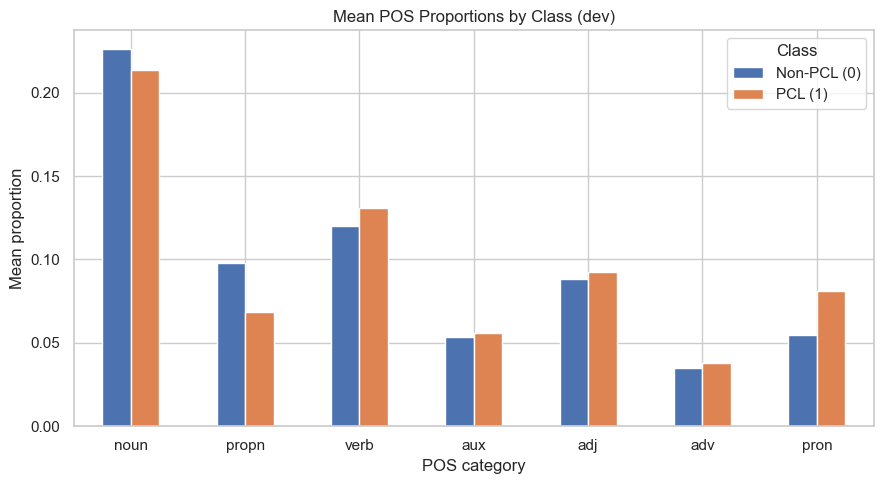

/var/folders/5q/3czvnrx53rj7m28pz74m031h0000gp/T/ipykernel_61959/1347696729.py:46: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  long_df.pivot_table(index="pos", columns="label_data", values="mean_prop", aggfunc="mean")


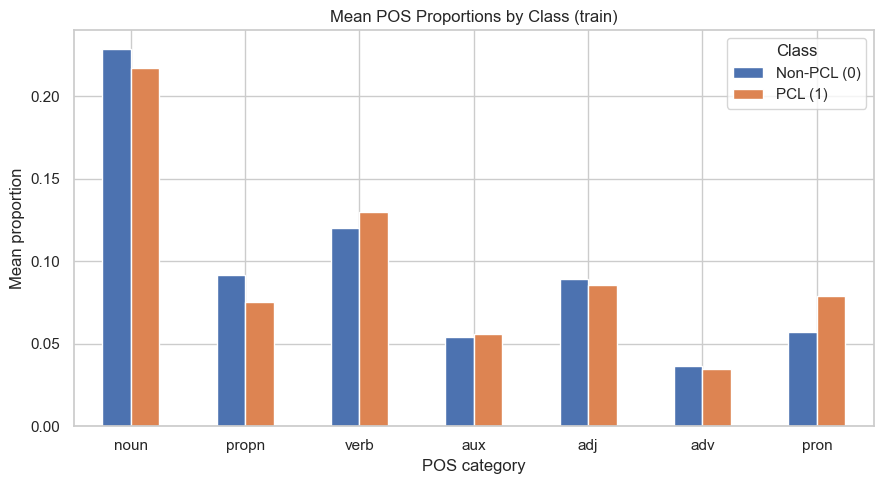

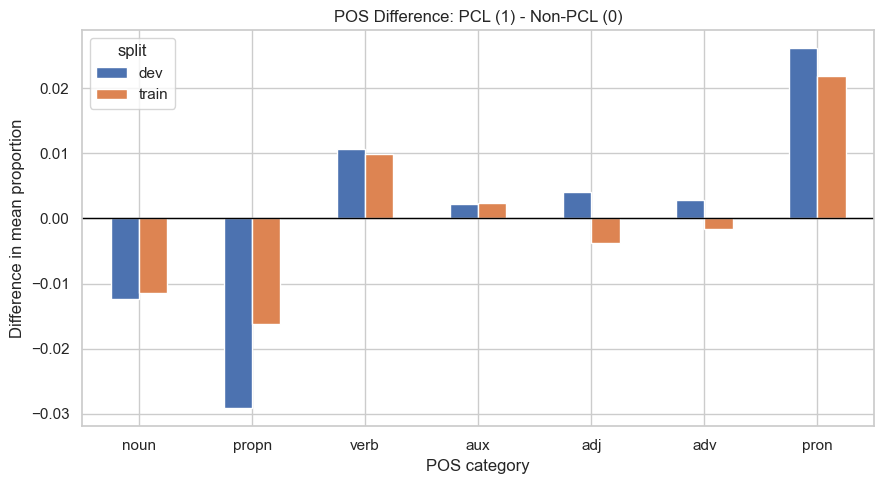

In [28]:
plot_pos_df = pd.concat(
    [df_train.assign(split="train"), df_dev.assign(split="dev")],
    ignore_index=True
)

selected_pos = ["noun", "propn", "verb", "aux", "adj", "adv", "pron"]
pos_prop_cols = [f"pos_prop_{p}" for p in selected_pos]

# Aggregate mean POS proportions by split and class
pos_summary = (
    plot_pos_df.groupby(["split", "label_data"])[pos_prop_cols]
    .mean()
    .reset_index()
)

# Rename POS columns to short names 
rename_map = {f"pos_prop_{p}": p for p in selected_pos}
pos_summary_display = pos_summary.rename(columns=rename_map)

display(pos_summary_display.round(4))

# Plot 1: ressults for both data sets
for split_name in ["dev", "train"]:
    sub = pos_summary_display[pos_summary_display["split"] == split_name].copy()
    if sub.empty:
        print(f"Skipping {split_name}: no data.")
        continue

    long_df = sub.melt(
        id_vars=["split", "label_data"],
        value_vars=selected_pos,
        var_name="pos",
        value_name="mean_prop"
    )

    long_df["mean_prop"] = pd.to_numeric(long_df["mean_prop"], errors="coerce")
    long_df = long_df.dropna(subset=["mean_prop"])
    if long_df.empty:
        print(f"Skipping {split_name}: no numeric data.")
        continue

    # enforce bar order
    long_df["pos"] = pd.Categorical(long_df["pos"], categories=selected_pos, ordered=True)

    pivot_df = (
        long_df.pivot_table(index="pos", columns="label_data", values="mean_prop", aggfunc="mean")
        .reindex(selected_pos)
    )

    pivot_df = pivot_df.rename(columns={0: "Non-PCL (0)", 1: "PCL (1)"})

    ax = pivot_df.plot(kind="bar", figsize=(9, 5), rot=0)
    ax.set_title(f"Mean POS Proportions by Class ({split_name})")
    ax.set_xlabel("POS category")
    ax.set_ylabel("Mean proportion")
    ax.legend(title="Class")
    plt.tight_layout()
    plt.savefig(Path("figures") / "eda_pos_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

# Plot 2: difference plot = PCL (1) - Non-PCL (0)
diff_rows = []
for split_name in ["train", "dev"]:
    sub = pos_summary_display[pos_summary_display["split"] == split_name].copy()

    if not {0, 1}.issubset(set(sub["label_data"].unique())):
        print(f"Skipping {split_name}: missing one of the classes (0/1).")
        continue

    row0 = sub[sub["label_data"] == 0].iloc[0]  # Non-PCL
    row1 = sub[sub["label_data"] == 1].iloc[0]  # PCL

    for p in selected_pos:
        diff_rows.append({
            "split": split_name,
            "pos": p,
            "diff": float(row1[p] - row0[p])  # PCL - Non-PCL
        })

diff_df = pd.DataFrame(diff_rows)

if diff_df.empty:
    print("No valid data for difference plot.")
else:
    diff_df["pos"] = pd.Categorical(diff_df["pos"], categories=selected_pos, ordered=True)

    pivot_diff = (
        diff_df.pivot(index="pos", columns="split", values="diff")
        .reindex(selected_pos)
    )

    ax = pivot_diff.plot(kind="bar", figsize=(9, 5), rot=0)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("POS Difference: PCL (1) - Non-PCL (0)")
    ax.set_xlabel("POS category")
    ax.set_ylabel("Difference in mean proportion")
    plt.tight_layout()
    plt.show()




In [29]:
# Remove duplicated columns caused by rerunning concat/merge cells
df_train = df_train.loc[:, ~df_train.columns.duplicated()].copy()
df_dev   = df_dev.loc[:, ~df_dev.columns.duplicated()].copy()

print("Train shape after dedup:", df_train.shape)
print("Dev shape after dedup:", df_dev.shape)

Train shape after dedup: (8375, 38)
Dev shape after dedup: (2094, 38)


In [30]:
# ============================================
# EDA Block 3.2.0: NER setup
# ============================================

# We already loaded:
# nlp = spacy.load("en_core_web_sm")
# nlp_pos = spacy.load("en_core_web_sm", disable=["ner"])

print("Full spaCy pipeline:", nlp.pipe_names)
assert "ner" in nlp.pipe_names, "NER component is missing from spaCy pipeline!"

# Quick sanity check
sample_doc = nlp(str(df_train["text"].iloc[0]))
print("Sample entities:", [(ent.text, ent.label_) for ent in sample_doc.ents[:10]])

Full spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Sample entities: [('an estimated 150,000', 'CARDINAL'), ('the British Empire', 'GPE'), ('between 1920 and 1974', 'DATE')]


### Now we focus on Named Entity Recognition (NER) to check if PCL label is linked to a specific named entity category.

In [31]:
# Common entity types to track
NER_TRACK = [
    "PERSON", "ORG", "GPE", "LOC", "NORP",
    "DATE", "CARDINAL", "MONEY", "PERCENT"
]

def extract_ner_features(texts, nlp_pipeline, batch_size=64):
    """
    Extract per-text NER counts and densities.
    Uses full spaCy pipeline (must include NER).
    """
    rows = []
    texts = ["" if pd.isna(t) else str(t) for t in texts]

    for doc in nlp_pipeline.pipe(texts, batch_size=batch_size):
        ents = list(doc.ents)
        ent_counts = Counter(ent.label_ for ent in ents)

        # Non-space, non-punct token count for normalization
        toks = [t for t in doc if not t.is_space and not t.is_punct]
        n_tokens = len(toks)
        n_ents = len(ents)

        row = {
            "ner_ent_count": n_ents,
            "ner_ent_density": (n_ents / n_tokens) if n_tokens > 0 else 0.0,
        }

        for lab in NER_TRACK:
            c = ent_counts.get(lab, 0)
            row[f"ner_count_{lab.lower()}"] = c
            row[f"ner_prop_{lab.lower()}"] = (c / n_ents) if n_ents > 0 else 0.0

        rows.append(row)

    return pd.DataFrame(rows)

# Run extraction
train_ner_feats = extract_ner_features(df_train["text"].tolist(), nlp, batch_size=64)
dev_ner_feats   = extract_ner_features(df_dev["text"].tolist(), nlp, batch_size=64)


ner_cols_existing_train = [c for c in df_train.columns if c.startswith("ner_")]
ner_cols_existing_dev   = [c for c in df_dev.columns if c.startswith("ner_")]

if ner_cols_existing_train:
    df_train = df_train.drop(columns=ner_cols_existing_train, errors="ignore")
if ner_cols_existing_dev:
    df_dev = df_dev.drop(columns=ner_cols_existing_dev, errors="ignore")

# Merge new NER features
df_train = pd.concat([df_train.reset_index(drop=True), train_ner_feats.reset_index(drop=True)], axis=1)
df_dev   = pd.concat([df_dev.reset_index(drop=True), dev_ner_feats.reset_index(drop=True)], axis=1)

print("NER features added.")
print("Train shape:", df_train.shape)
print("Dev shape:", df_dev.shape)

# Preview
preview_cols = ["text", "label_data" if "label_data" in df_train.columns else "label",
                "ner_ent_count", "ner_ent_density"] + [f"ner_count_{x.lower()}" for x in ["PERSON","ORG","GPE"]]
display(df_train[preview_cols].head(5))

NER features added.
Train shape: (8375, 58)
Dev shape: (2094, 58)


,text,label_data,ner_ent_count,ner_ent_density,ner_count_person,ner_count_org,ner_count_gpe
0,"The scheme saw an estimated 150,000 children f...",1,3,0.088235,0,0,1
1,Durban 's homeless communities reconciliation ...,1,1,0.166667,0,1,0
2,The next immediate problem that cropped up was...,1,0,0.000000,0,0,0
3,Far more important than the implications for t...,1,3,0.075000,0,0,0
4,To strengthen child-sensitive social protectio...,1,0,0.000000,0,0,0


In [32]:
# Build combined frame
ner_plot_df = pd.concat(
    [df_train.assign(split="train"), df_dev.assign(split="dev")],
    ignore_index=True
)

# Remove duplicate columns 
ner_plot_df = ner_plot_df.loc[:, ~ner_plot_df.columns.duplicated()].copy()

# Build summary
ner_summary = (
    ner_plot_df
    .groupby(["split", "label_data"])[["ner_ent_count", "ner_ent_density"]]
    .agg(["mean", "median"])
)

# Flatten multi-index columns
ner_summary.columns = [f"{a}_{b}" for a, b in ner_summary.columns]
ner_summary = ner_summary.reset_index()

display(ner_summary.round(4))

,split,label_data,ner_ent_count_mean,ner_ent_count_median,ner_ent_density_mean,ner_ent_density_median
0,dev,0,3.4923,3.0,0.0872,0.0784
1,dev,1,2.6030,2.0,0.0538,0.0417
2,train,0,3.4648,3.0,0.0833,0.0727
3,train,1,2.7620,2.0,0.0586,0.0500


### Now we look at specific NER categories:

,split,label_data,ner_prop_person,ner_prop_org,ner_prop_gpe,ner_prop_loc,ner_prop_norp,ner_prop_date,ner_prop_cardinal
0,dev,0,0.1648,0.2074,0.1741,0.0225,0.0870,0.1357,0.1257
1,dev,1,0.2251,0.1821,0.1712,0.0318,0.0775,0.1396,0.1041
2,train,0,0.1609,0.1991,0.1794,0.0213,0.0830,0.1370,0.1315
3,train,1,0.2041,0.2020,0.1500,0.0197,0.0839,0.1413,0.1001


/var/folders/5q/3czvnrx53rj7m28pz74m031h0000gp/T/ipykernel_61959/961379481.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(index="ner_type", columns="class_name", values="mean_prop", aggfunc="mean")


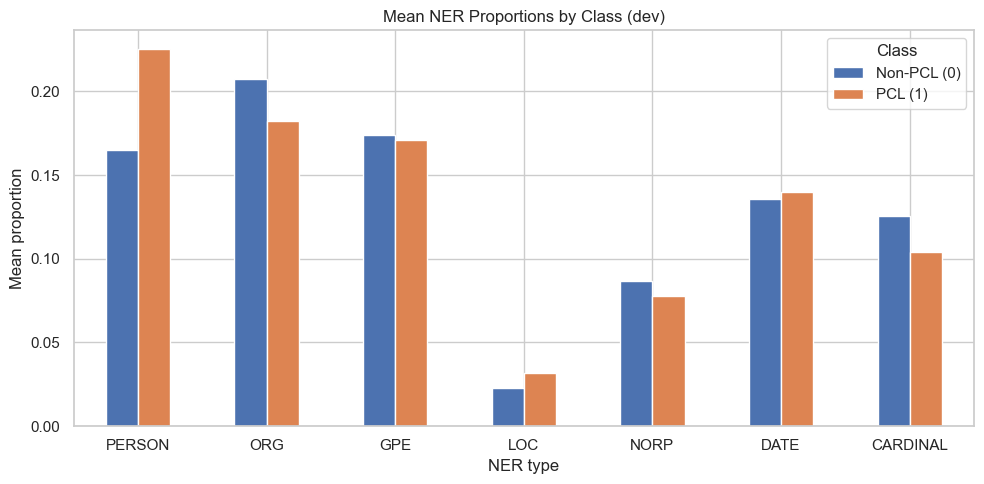

/var/folders/5q/3czvnrx53rj7m28pz74m031h0000gp/T/ipykernel_61959/961379481.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(index="ner_type", columns="class_name", values="mean_prop", aggfunc="mean")


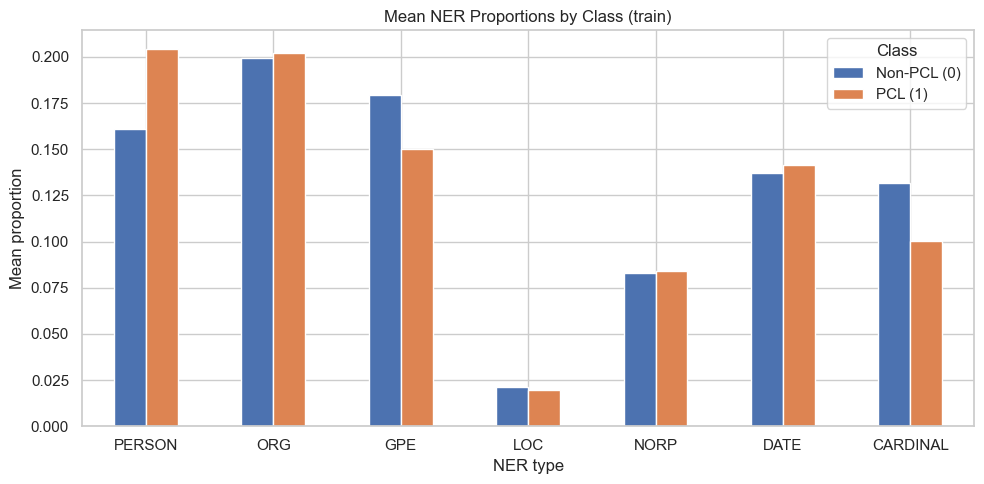

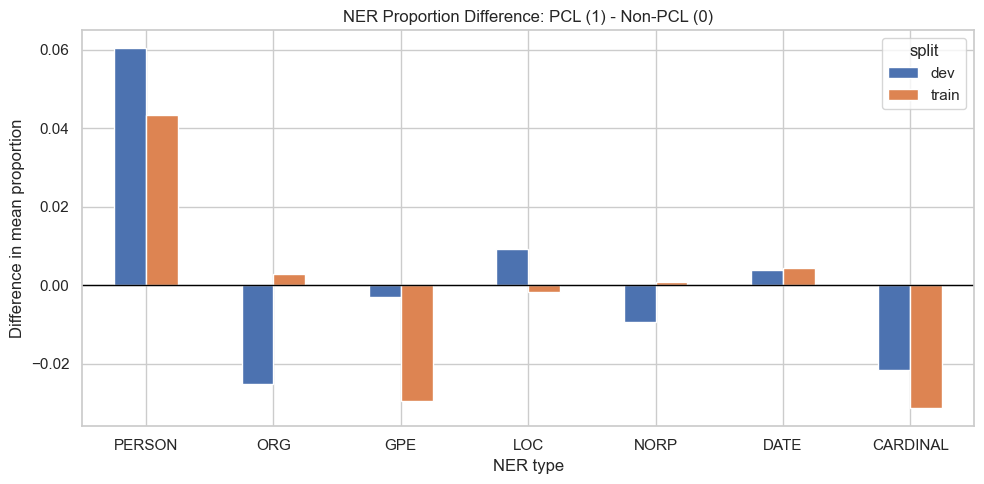

In [35]:
selected_ner_types = ["person", "org", "gpe", "loc", "norp", "date", "cardinal"]
ner_prop_cols = [f"ner_prop_{t}" for t in selected_ner_types]

ner_comp_df = pd.concat(
    [df_train.assign(split="train"), df_dev.assign(split="dev")],
    ignore_index=True
)
ner_comp_df = ner_comp_df.loc[:, ~ner_comp_df.columns.duplicated()].copy()

# Restrict to rows with at least one entity 
ner_comp_nonzero = ner_comp_df[ner_comp_df["ner_ent_count"] > 0].copy()

ner_type_summary = (
    ner_comp_nonzero
    .groupby(["split", "label_data"])[ner_prop_cols]
    .mean()
    .reset_index()
)

display(ner_type_summary.round(4))

# Plots 1 and 2: grouped bars by split (class 0 vs 1) 
type_order = selected_ner_types  

plot_rows = []
for _, row in ner_type_summary.iterrows():
    split_name = row["split"]
    cls = row["label_data"]
    cls_name = "PCL (1)" if cls == 1 else "Non-PCL (0)"
    for t in type_order:
        col = f"ner_prop_{t}"
        plot_rows.append({
            "split": split_name,
            "class_name": cls_name,
            "ner_type": t.upper(),
            "mean_prop": row[col]
        })

ner_plot_df = pd.DataFrame(plot_rows)
ner_plot_df["mean_prop"] = pd.to_numeric(ner_plot_df["mean_prop"], errors="coerce")
ner_plot_df = ner_plot_df.dropna(subset=["mean_prop"])

for split_name in ["dev", "train"]:
    tmp = ner_plot_df[ner_plot_df["split"] == split_name].copy()
    if tmp.empty:
        print(f"Skipping {split_name}: no data.")
        continue

    tmp["ner_type"] = pd.Categorical(
        tmp["ner_type"],
        categories=[t.upper() for t in type_order],
        ordered=True
    )

    pivot_tmp = (
        tmp.pivot_table(index="ner_type", columns="class_name", values="mean_prop", aggfunc="mean")
        .reindex([t.upper() for t in type_order])
    )

    ax = pivot_tmp.plot(kind="bar", figsize=(10, 5), rot=0)
    ax.set_title(f"Mean NER Proportions by Class ({split_name})")
    ax.set_xlabel("NER type")
    ax.set_ylabel("Mean proportion")
    ax.legend(title="Class")
    plt.tight_layout()
    plt.savefig(Path("figures") / "eda_ner_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


# Plot 3: difference plot (PCL - Non-PCL)
diff_rows = []
for split_name in ["train", "dev"]:
    sub = ner_type_summary[ner_type_summary["split"] == split_name].copy()
    classes = set(sub["label_data"].unique())
    if not {0, 1}.issubset(classes):
        print(f"Skipping diff for {split_name}: missing class 0 or 1.")
        continue

    row0 = sub[sub["label_data"] == 0].iloc[0]
    row1 = sub[sub["label_data"] == 1].iloc[0]

    for t in type_order:
        col = f"ner_prop_{t}"
        diff_rows.append({
            "split": split_name,
            "ner_type": t.upper(),
            "diff_pcl_minus_nonpcl": float(row1[col] - row0[col])
        })

ner_diff_df = pd.DataFrame(diff_rows)

if not ner_diff_df.empty:
    ner_diff_df["ner_type"] = pd.Categorical(
        ner_diff_df["ner_type"],
        categories=[t.upper() for t in type_order],
        ordered=True
    )

    pivot_diff = (
        ner_diff_df.pivot(index="ner_type", columns="split", values="diff_pcl_minus_nonpcl")
        .reindex([t.upper() for t in type_order])
    )

    ax = pivot_diff.plot(kind="bar", figsize=(10, 5), rot=0)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("NER Proportion Difference: PCL (1) - Non-PCL (0)")
    ax.set_xlabel("NER type")
    ax.set_ylabel("Difference in mean proportion")
    plt.tight_layout()
    plt.show()
else:
    print("No valid data for difference plot.")


In [36]:
# Cleaning up
df_train = df_train.loc[:, ~df_train.columns.duplicated()].copy()
df_dev   = df_dev.loc[:, ~df_dev.columns.duplicated()].copy()

print("Train shape:", df_train.shape)
print("Dev shape:", df_dev.shape)

Train shape: (8375, 58)
Dev shape: (2094, 58)


## 2.4 Noise & Artifact Detection

### Set-up:

In [37]:
eda4_df = pd.concat(
    [df_train.assign(split="train"), df_dev.assign(split="dev")],
    ignore_index=True
)
eda4_df = eda4_df.loc[:, ~eda4_df.columns.duplicated()].copy()
eda4_df["text_str"] = eda4_df["text"].fillna("").astype(str)

print("Combined shape:", eda4_df.shape)
display(eda4_df[["split", "par_id", "label_data", "text"]].head(3))

Combined shape: (10469, 60)


,split,par_id,label_data,text
0,train,4341,1,"The scheme saw an estimated 150,000 children f..."
1,train,4136,1,Durban 's homeless communities reconciliation ...
2,train,10352,1,The next immediate problem that cropped up was...


### Check for Missing / empty / whitespace-only texts:

In [38]:
eda4_df["is_text_na"] = eda4_df["text"].isna()
eda4_df["is_text_empty"] = eda4_df["text_str"].eq("")
eda4_df["is_text_whitespace_only"] = eda4_df["text_str"].str.strip().eq("")

missing_summary = (
    eda4_df.groupby("split")[["is_text_na", "is_text_empty", "is_text_whitespace_only"]]
    .sum()
    .reset_index()
)
display(missing_summary)

# Show examples if any
problem_rows = eda4_df[
    eda4_df["is_text_na"] | eda4_df["is_text_empty"] | eda4_df["is_text_whitespace_only"]
][["split", "par_id", "label_data", "text"]]

print("Problem text rows:", len(problem_rows))
display(problem_rows.head(20))

,split,is_text_na,is_text_empty,is_text_whitespace_only
0,dev,0,1,1
1,train,0,0,0


Problem text rows: 1


,split,par_id,label_data,text
8809,dev,8640,0,


### Now we check for duplicates within a dataset and cross split

In [39]:
# Normalized exact-match key 
eda4_df["text_exact_key"] = eda4_df["text_str"].str.strip()

# A) Duplicates within each split
dup_within = (
    eda4_df.groupby(["split", "text_exact_key"])
    .size()
    .reset_index(name="count")
)
dup_within = dup_within[dup_within["count"] > 1].sort_values(["split", "count"], ascending=[True, False])

dup_within_summary = (
    dup_within.groupby("split")["count"]
    .agg(["count", "sum"])
    .reset_index()
    .rename(columns={"count": "n_duplicate_groups", "sum": "n_rows_in_duplicate_groups"})
)

print("Within-split duplicate groups:")
display(dup_within_summary if not dup_within_summary.empty else pd.DataFrame({"message": ["No within-split exact duplicates found"]}))

# B) Cross-split leakage check: same exact text appears in both train and dev
train_keys = set(eda4_df.loc[eda4_df["split"] == "train", "text_exact_key"])
dev_keys   = set(eda4_df.loc[eda4_df["split"] == "dev", "text_exact_key"])
cross_overlap_keys = train_keys.intersection(dev_keys)

print("Number of exact text overlaps between train and dev:", len(cross_overlap_keys))

if len(cross_overlap_keys) > 0:
    cross_overlap_examples = eda4_df[eda4_df["text_exact_key"].isin(list(cross_overlap_keys))] \
        [["split", "par_id", label_col, "text"]] \
        .sort_values(["text", "split"])
    display(cross_overlap_examples.head(20))
else:
    print("No exact train-dev text overlap detected.")

Within-split duplicate groups:


,message
0,No within-split exact duplicates found


Number of exact text overlaps between train and dev: 0
No exact train-dev text overlap detected.


Next, we check for formatting artifacts and noisy patterns

In [41]:
# Formatting artifacts and noisy patterns

patterns = {
    "contains_url": r"https?://|www\.",
    "contains_html_tag": r"<[^>]+>",
    "contains_html_entity": r"&[a-zA-Z]+;",
    "contains_literal_newline": r"\\n",            # literal backslash-n
    "contains_multiple_quotes": r"['\"]{2,}",      # repeated quotes like """" or ''
    "contains_repeated_punct": r"[!?.,;:]{3,}",
    "contains_non_ascii": r"[^\x00-\x7F]",
}

for feat, pat in patterns.items():
    eda4_df[feat] = eda4_df["text_str"].str.contains(pat, regex=True, na=False)

artifact_summary = (
    eda4_df.groupby("split")[list(patterns.keys())]
    .mean()
    .reset_index()
)

# Convert to percentages for readability
artifact_summary_pct = artifact_summary.copy()
for c in patterns.keys():
    artifact_summary_pct[c] = (artifact_summary_pct[c] * 100).round(2)

display(artifact_summary_pct)

# Optional: inspect examples for selected artifacts
for feat in ["contains_multiple_quotes", "contains_html_entity", "contains_url", "contains_literal_newline"]:
    n = int(eda4_df[feat].sum())
    print(f"\n{feat}: {n} rows")
    if n > 0:
        display(eda4_df.loc[eda4_df[feat], ["split", "par_id", "label_data", "text"]].head(5))

,split,contains_url,contains_html_tag,contains_html_entity,contains_literal_newline,contains_multiple_quotes,contains_repeated_punct,contains_non_ascii
0,dev,0.10,4.06,0.62,0.0,24.07,2.24,0.0
1,train,0.08,3.77,0.78,0.0,25.01,2.67,0.0



contains_multiple_quotes: 2599 rows


,split,par_id,label_data,text
7,train,9343,1,"""Lougene has this message to others who may st..."
15,train,2385,1,""""""" Bruce has done a fantastic job in training..."
16,train,4491,1,""""""" Volleyball is our reputation in schools ' ..."
17,train,2872,1,"""Ms. Archibald """" had room in her heart for ev..."
20,train,853,1,"""Iain Duncan-Smith has made his feelings about..."



contains_html_entity: 78 rows


,split,par_id,label_data,text
12,train,951,1,"Together with wife Vicky , Cornell established..."
43,train,266,1,""""""" As Briggs &amp; Stratton celebrates its 11..."
125,train,1542,1,"""He was born HIV-positive . He 's healthy , bu..."
421,train,8569,1,Muniba 's was n't an easy journey and yet she ...
461,train,9673,1,""""""" At ONYX , we care not only for the wellbei..."



contains_url: 9 rows


,split,par_id,label_data,text
2715,train,2141,0,Under the 1st phase Viru Sara card will be giv...
3903,train,3451,0,For other USCIS services that were offered thr...
4504,train,4106,0,About United Way Greater Los Angeles : United ...
4818,train,4453,0,"""Sindh decides to register , collect data of a..."
6210,train,5981,0,"According to www.politifact.com , Trump wants ..."



contains_literal_newline: 0 rows


Next is outlier detection (length and character composition)

In [42]:
# Basic character composition features
eda4_df["char_len"] = eda4_df["text_str"].str.len()
eda4_df["digit_count"] = eda4_df["text_str"].str.count(r"\d")
eda4_df["punct_count"] = eda4_df["text_str"].str.count(r"[^\w\s]")  # rough punctuation count

if "word_len" in eda4_df.columns:
    eda4_df["word_count_tmp"] = eda4_df["word_len"]
else:
    eda4_df["word_count_tmp"] = eda4_df["text_str"].str.split().str.len()

# Ratios 
eda4_df["digit_ratio"] = np.where(eda4_df["char_len"] > 0, eda4_df["digit_count"] / eda4_df["char_len"], 0.0)
eda4_df["punct_ratio"] = np.where(eda4_df["char_len"] > 0, eda4_df["punct_count"] / eda4_df["char_len"], 0.0)

# Thresholds
eda4_df["is_very_short"] = eda4_df["word_count_tmp"] <= 3
eda4_df["is_very_long"] = eda4_df["word_count_tmp"] >= eda4_df["word_count_tmp"].quantile(0.98)
eda4_df["is_punct_heavy"] = eda4_df["punct_ratio"] >= eda4_df["punct_ratio"].quantile(0.95)

outlier_summary = (
    eda4_df.groupby("split")[["is_very_short", "is_very_long", "is_punct_heavy"]]
    .mean()
    .reset_index()
)

for c in ["is_very_short", "is_very_long", "is_punct_heavy"]:
    outlier_summary[c] = (outlier_summary[c] * 100).round(2)

display(outlier_summary)

# Inspect examples
print("\nVery short examples:")
display(eda4_df.loc[eda4_df["is_very_short"], ["split", "par_id", "label_data", "text"]].head(10))

print("\nPunctuation-heavy examples:")
display(eda4_df.loc[eda4_df["is_punct_heavy"], ["split", "par_id", "label_data", "text", "punct_ratio"]]
        .sort_values("punct_ratio", ascending=False).head(10))

print("\nVery long examples:")
display(eda4_df.loc[eda4_df["is_very_long"], ["split", "par_id", "label_data", "text", "word_count_tmp"]]
        .sort_values("word_count_tmp", ascending=False).head(10))

,split,is_very_short,is_very_long,is_punct_heavy
0,dev,0.10,1.91,5.30
1,train,0.06,2.05,4.96



Very short examples:


,split,par_id,label_data,text
1083,train,318,0,The Filipino immigrant
2266,train,1657,0,refugees
2542,train,1955,0,Review refugee law
3601,train,3121,0,*Fighting over men/women
6244,train,6021,0,Pretty much hopeless
8809,dev,8640,0,
9192,dev,9064,0,Feeling hopeless



Punctuation-heavy examples:


,split,par_id,label_data,text,punct_ratio
8013,train,7985,0,""""""" I 'm disabled , not unable ... BRO . """"""",0.272727
8008,train,7979,0,a good car but seriously in need of an update ...,0.178571
1165,train,412,0,""""""" ... gender inequality hits women squarely ...",0.144928
6694,train,6533,0,""""""" At first I felt hopeless , """" said Ms. Sav...",0.142857
2051,train,1415,0,""""""" We 've given clear commitment to child ref...",0.140351
3705,train,3235,0,"""Another name for homeless people in Spanish-s...",0.139344
9433,dev,9325,0,"""The man was """" a very vulnerable patient """" ,...",0.137931
9967,dev,9916,0,""""""" He was not a bum or a homeless guy , """" ad...",0.135593
3341,train,2830,0,""""""" It 's up to the company ... and it 's up t...",0.133929
2940,train,2389,0,""""""" I was homeless and you gave me a home """"""",0.133333



Very long examples:


,split,par_id,label_data,text,word_count_tmp
7489,train,7419,0,"""Dr Mayengbam Lalit Singh Recently honourable ...",909
643,train,6833,1,"""Most are from desperately poor Horn of Africa...",512
6207,train,5978,0,"""Mahinda Wijesinghe , the Inspector General of...",419
8203,train,8192,0,ANNUAL State of Education Report ( ASER ) laun...,390
9870,dev,9811,0,Two goals in the third quarter put the Ballysh...,272
1058,train,293,0,"""The following is a brief history of the Rajne...",266
25,train,7853,1,"""Islamic philosophy has dealt at length with t...",252
6500,train,6315,0,"""I ran into one of my high school teachers rec...",230
5776,train,5494,0,"""The importance of an assessment to evaluate t...",220
7855,train,7810,0,Equally to coincide with the 20th anniversary ...,214
